In [1]:
# change directory to working directory
working_dir = '/home/jj/Research/ConceptualSensitivityRegularization/'
import os
os.chdir(working_dir)

import matplotlib.pyplot as plt
import pandas as pd
import os
import yaml

# load local path yaml file
local_path = 'configs/dataset/local_path.yaml'
with open(local_path) as file:
    dat = yaml.load(file, Loader=yaml.FullLoader)


# Waterbirds

- `metadata.csv` file ccontains all of the informations including which place file was used to compose waterbirds images
- `metadata_waterbirds.csv` file is used on Dataset classes

In [2]:
wdf1 = pd.read_csv(os.path.join(dat['waterbirds_path'], 'waterbird_complete95_forest2water2/metadata.csv'))
wdf2 = pd.read_csv(os.path.join(dat['waterbirds_path'], 'waterbird_complete95_forest2water2/metadata_waterbirds.csv'))

print(wdf1.keys(), wdf2.keys())
wdf1.tail(2)


Index(['img_id', 'img_filename', 'y', 'split', 'place', 'place_filename'], dtype='object') Index(['id', 'filename', 'split', 'y', 'a'], dtype='object')


,img_id,img_filename,y,split,place,place_filename
11786,11787,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,0,0,/b/bamboo_forest/00004628.jpg
11787,11788,200.Common_Yellowthroat/Common_Yellowthroat_00...,0,2,1,/o/ocean/00001069.jpg


# Checking whether place filename exists in Place365

{'/l/lake/natural', '/f/forest/broadleaf', '/b/bamboo_forest', '/o/ocean'}


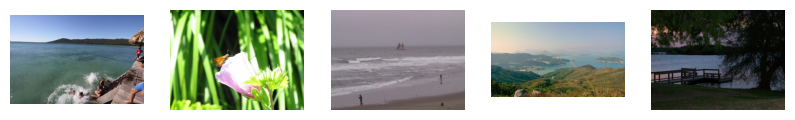

In [3]:
# which backgrounds do waterbirds dataset use?
print(set(['/'.join(i.split('/')[:-1]) for i in wdf1['place_filename']]))

# plot some example images
p365_path = os.path.join(dat['place365'], 'data_large')

import matplotlib.pyplot as plt

def plot_images(df, n=5):
    fig, ax = plt.subplots(1, n, figsize=(n*2, 2))
    for i in range(n):
        file_path = p365_path + df['place_filename'].iloc[i+1]
        img = plt.imread(file_path)
        ax[i].imshow(img)
        ax[i].axis('off')
    plt.show()

plot_images(wdf1)

In [4]:
# Checking the integrity of dataset
# check if all files exist
import os

def check_files_exist(df):
    for i in range(len(df)):
        file_path = p365_path + df['place_filename'].iloc[i]
        if not os.path.exists(file_path):
            return print('file does not exist:', file_path)
    print('all files exist')

check_files_exist(wdf1)

all files exist


In [5]:
# To do lists
# 1. constructing concept dataset file list
bg_series = wdf1['place_filename'].apply(lambda x: '/'.join(x.split('/')[:-1]))
print(bg_series.value_counts())

# 2. count the number of images in each background that is in Place365 directory
for bg in bg_series.unique():
    print(bg, len(os.listdir(p365_path + bg)))

place_filename
/b/bamboo_forest       3534
/f/forest/broadleaf    3517
/l/lake/natural        2374
/o/ocean               2363
Name: count, dtype: int64
/o/ocean 5000
/l/lake/natural 5000
/b/bamboo_forest 5000
/f/forest/broadleaf 5000


# Extracting bgs not in waterbirds

In [6]:
bgs_not_in_waterbirds = {}
for bg in bg_series.unique():
    p365_bg_list = os.listdir(p365_path + bg)
    waterbirds_bg_list = wdf1['place_filename']

    bgs_not_in_waterbirds[bg] = [bg[1:]+'/'+i for i in p365_bg_list if bg+'/'+i not in waterbirds_bg_list.values]

In [7]:
bgs_not_in_waterbirds.keys()

for k, v in bgs_not_in_waterbirds.items():
    print(k, len(v))


/o/ocean 2637
/l/lake/natural 2626
/b/bamboo_forest 1466
/f/forest/broadleaf 1483


In [8]:
concept_dict = {
    "water": bgs_not_in_waterbirds["/o/ocean"] + bgs_not_in_waterbirds["/l/lake/natural"],
    "land": bgs_not_in_waterbirds["/b/bamboo_forest"] + bgs_not_in_waterbirds["/f/forest/broadleaf"],
}

In [9]:
# shuffle
import random
for k, v in concept_dict.items():
    random.shuffle(v)
    

In [10]:
# Write yaml file for the background images that are not in waterbirds dataset
import yaml

with open('configs/dataset/waterbirds_concepts.yaml', 'w') as file:
    yaml.dump(concept_dict, file)



In [26]:
ocean = [i for i in wdf1['place_filename'].values if 'o/ocean' in i]
lake = [i for i in wdf1['place_filename'].values if 'l/lake/natural' in i]
bamboo = [i for i in wdf1['place_filename'].values if 'b/bamboo_forest' in i]
forest = [i for i in wdf1['place_filename'].values if 'f/forest/broadleaf' in i]

concept_dict = {
    "water": [i[1:] for i in ocean + lake],
    "land": [i[1:] for i in bamboo + forest],
}

# shuffle
import random
for k, v in concept_dict.items():
    random.shuffle(v)

# Write yaml file for the background images that are in waterbirds dataset
import yaml

with open('configs/dataset/waterbirds_used_bgs.yaml', 'w') as file:
    yaml.dump(concept_dict, file)